<a href="https://colab.research.google.com/github/MarcSan18/analise_vendas_inteligencia_comercial/blob/main/analise_vendas_inteligencia_comercial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install notebook pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:00


In [8]:
import pandas as pd

dados = {
    "data": ["2024-01-01","2024-01-02","2024-01-03","2024-01-04","2024-01-05","2024-01-06","2024-01-07"],
    "produto": ["Notebook","Mouse","Cadeira","Teclado","Mesa","Monitor","Sofa"],
    "categoria": ["Eletronicos","Eletronicos","Moveis","Eletronicos","Moveis","Eletronicos","Moveis"],
    "valor": [3500,80,900,150,1200,1800,2500],
    "quantidade": [1,2,1,1,1,1,1],
    "canal": ["Online","Loja","Online","Online","Loja","Online","Loja"]
}

df = pd.DataFrame(dados)
df

,data,produto,categoria,valor,quantidade,canal
0,2024-01-01,Notebook,Eletronicos,3500,1,Online
1,2024-01-02,Mouse,Eletronicos,80,2,Loja
2,2024-01-03,Cadeira,Moveis,900,1,Online
3,2024-01-04,Teclado,Eletronicos,150,1,Online
4,2024-01-05,Mesa,Moveis,1200,1,Loja
5,2024-01-06,Monitor,Eletronicos,1800,1,Online
6,2024-01-07,Sofa,Moveis,2500,1,Loja


In [9]:
# Informações do dataset
df.info()

# Estatísticas
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   data        7 non-null      object
 1   produto     7 non-null      object
 2   categoria   7 non-null      object
 3   valor       7 non-null      int64 
 4   quantidade  7 non-null      int64 
 5   canal       7 non-null      object
dtypes: int64(2), object(4)
memory usage: 468.0+ bytes


,valor,quantidade
count,7.000000,7.000000
mean,1447.142857,1.142857
std,1248.955754,0.377964
min,80.000000,1.000000
25%,525.000000,1.000000
50%,1200.000000,1.000000
75%,2150.000000,1.000000
max,3500.000000,2.000000


In [17]:
# Analise por faturamento

faturamento_total = df["valor"].sum()
print("Faturamento total:", faturamento_total)

# Analise por categoria
categoria = df.groupby("categoria")["valor"].sum()
print("\nVendas por categoria:\n", categoria)

# Analise por canal
canal = df.groupby("canal")["valor"].sum()
print("\nVendas por canal:\n", canal)

Faturamento total: 10130

Vendas por categoria:
 categoria
Eletronicos    5530
Moveis         4600
Name: valor, dtype: int64

Vendas por canal:
 canal
Loja      3780
Online    6350
Name: valor, dtype: int64


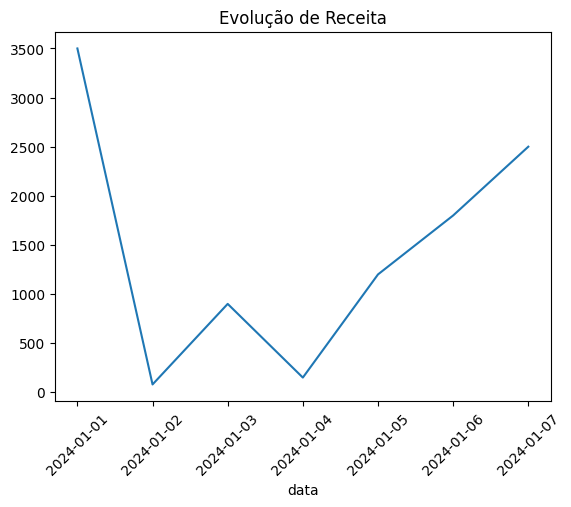

In [5]:
import matplotlib.pyplot as plt

# Agrupar por data
df_group = df.groupby("data")["valor"].sum()

df_group.plot()
plt.title("Evolução de Receita")
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


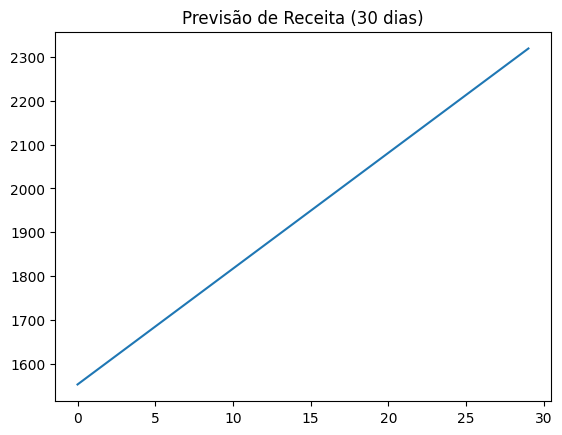

In [6]:
# Previsão de Receita com Machine Learning
#Foi utilizado um modelo de regressão linear para estimar a receita futura com base no comportamento histórico dos dados.

from sklearn.linear_model import LinearRegression
import numpy as np

df["data"] = pd.to_datetime(df["data"])
df["dia"] = df["data"].map(pd.Timestamp.toordinal)

X = df[["dia"]]
y = df["valor"]

modelo = LinearRegression()
modelo.fit(X, y)

# previsão 30 dias
futuros = np.array([[df["dia"].max() + i] for i in range(1, 31)])
previsoes = modelo.predict(futuros)

plt.plot(previsoes)
plt.title("Previsão de Receita (30 dias)")
plt.show()

In [7]:
# INSIGHTS DE NEGÓCIO

print("INSIGHTS:\n")

print("- Faturamento total:", df["valor"].sum())

print("- Categoria com maior faturamento:")
print(df.groupby("categoria")["valor"].sum().idxmax())

print("- Canal mais lucrativo:")
print(df.groupby("canal")["valor"].sum().idxmax())

INSIGHTS:

- Faturamento total: 10130
- Categoria com maior faturamento:
Eletronicos
- Canal mais lucrativo:
Online


**📊 Análise de Vendas e Inteligência Comercial**

Este projeto tem como objetivo analisar dados de vendas para identificar padrões, gerar insights estratégicos e apoiar a tomada de decisão.

  
***A análise inclui:***  
  

Avaliação de desempenho por categoria e canal

Identificação de oportunidades de crescimento

Previsão de receita com modelo de Machine Learning


***Recomendações de Negócio***


Aumentar investimento em canais digitais

Priorizar produtos com maior ticket médio

Criar estratégias para impulsionar categorias com menor desempenho

Utilizar previsões para planejamento de vendas